# Day 2: EDA, 상관관계 분석, 이벤트 분석

## 분석 목차
1. 데이터 로드 및 환경 설정
2. 기초 통계 및 분포 분석
3. 시계열 추이 분석
4. 상관관계 분석 (삼성전자 ↔ 외부 변수)
5. 롤링 상관계수 분석 (시간에 따른 관계 변화)
6. 이벤트 전후 주가 반응 분석
7. 변동성 분석 (GARCH-like)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats

# 한글 폰트
import platform
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# 경로
PROJECT_ROOT    = Path('..').resolve()
PROCESSED_DIR   = PROJECT_ROOT / 'data' / 'processed'
FIG_DIR         = PROCESSED_DIR  # 시각화도 processed에 저장

# 데이터 로드
master  = pd.read_csv(PROCESSED_DIR / 'master_close.csv',  index_col='Date', parse_dates=True)
returns = pd.read_csv(PROCESSED_DIR / 'daily_returns.csv', index_col='Date', parse_dates=True)

print(f'종가 데이터: {master.shape}  |  수익률 데이터: {returns.shape}')
print(f'기간: {master.index.min().date()} ~ {master.index.max().date()}')
master.head(3)

종가 데이터: (1304, 10)  |  수익률 데이터: (1303, 10)
기간: 2020-01-01 ~ 2024-12-30


,samsung,skhynix,naver,kospi,usdkrw,wti,gold,us10y,sp500,nasdaq
Date,,,,,,,,,,
2020-01-01,NaN,NaN,NaN,NaN,1153.750000,NaN,NaN,NaN,NaN,NaN
2020-01-02,47470.902344,88898.828125,177355.468750,2175.169922,1153.969971,61.180000,1524.500000,1.882,3257.850098,9092.190430
2020-01-03,47728.890625,88711.093750,176383.640625,2176.459961,1157.150024,63.049999,1549.199951,1.788,3234.850098,9020.769531


## 1. 기초 통계 및 수익률 분포

In [2]:
# ── 연간 수익률·변동성 요약 ─────────────────────────────────
ann_return = returns.mean() * 252
ann_vol    = returns.std()  * np.sqrt(252)
sharpe     = ann_return / ann_vol
skewness   = returns.skew()
kurtosis   = returns.kurtosis()   # excess kurtosis

summary = pd.DataFrame({
    '연간수익률(%)' : (ann_return * 100).round(1),
    '연간변동성(%)' : (ann_vol    * 100).round(1),
    '샤프지수'      : sharpe.round(2),
    '왜도'          : skewness.round(3),
    '초과첨도'      : kurtosis.round(3),
    '최대낙폭일수익률(%)': (returns.min() * 100).round(2),
    '최대상승일수익률(%)': (returns.max() * 100).round(2),
})

print('=== 기초 통계 요약 ===')
display(summary.style
    .background_gradient(subset=['연간수익률(%)'], cmap='RdYlGn', vmin=-30, vmax=60)
    .background_gradient(subset=['연간변동성(%)'], cmap='YlOrRd', vmin=5, vmax=40)
    .background_gradient(subset=['샤프지수'],      cmap='RdYlGn', vmin=-0.5, vmax=2)
    .format({'연간수익률(%)': '{:.1f}', '연간변동성(%)': '{:.1f}', '샤프지수': '{:.2f}'})
)

=== 기초 통계 요약 ===


,연간수익률(%),연간변동성(%),샤프지수,왜도,초과첨도,최대낙폭일수익률(%),최대상승일수익률(%)
samsung,2.2,26.7,0.08,0.385000,3.605000,-10.300000,10.470000
skhynix,11.3,39.0,0.29,0.271000,2.179000,-10.400000,13.400000
naver,9.6,35.1,0.27,0.437000,2.056000,-8.930000,9.940000
kospi,3.0,20.1,0.15,-0.203000,7.346000,-8.770000,8.600000
usdkrw,5.1,9.1,0.57,-0.345000,2.364000,-3.440000,2.070000
wti,27.5,50.6,0.54,0.264000,19.894000,-24.590000,25.100000
gold,12.1,16.3,0.74,-0.236000,3.682000,-4.980000,5.950000
us10y,35.4,70.4,0.50,5.838000,102.479000,-29.320000,73.900000
sp500,16.7,21.5,0.77,-0.528000,13.190000,-11.980000,9.380000
nasdaq,21.2,25.6,0.83,-0.433000,6.289000,-12.320000,9.350000


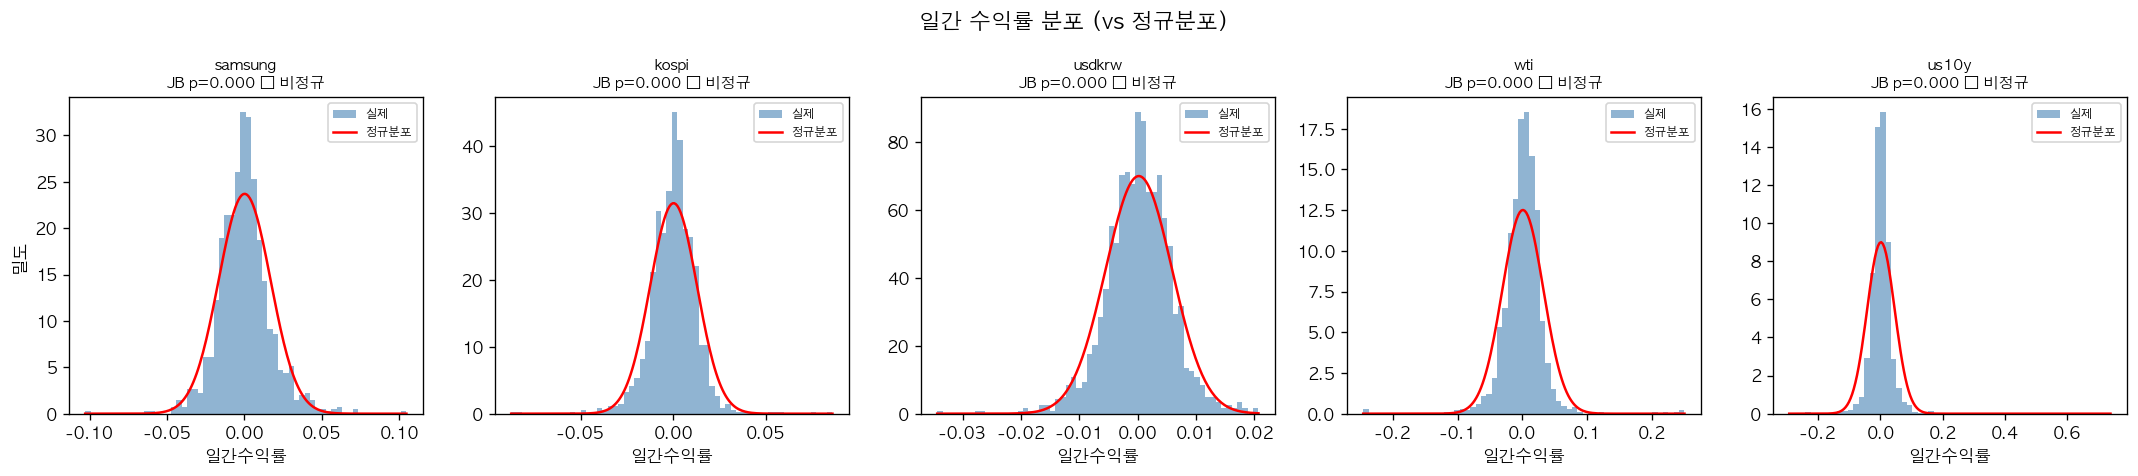

In [3]:
# ── 수익률 분포 (정규성 검정 포함) ──────────────────────────
target_cols = ['samsung', 'kospi', 'usdkrw', 'wti', 'us10y']

fig, axes = plt.subplots(1, len(target_cols), figsize=(18, 4))
fig.suptitle('일간 수익률 분포 (vs 정규분포)', fontsize=13, fontweight='bold')

for ax, col in zip(axes, target_cols):
    data = returns[col].dropna()
    ax.hist(data, bins=60, density=True, alpha=0.6, color='steelblue', label='실제')

    # 정규분포 곡선
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=1.5, label='정규분포')

    # Jarque-Bera 검정
    jb_stat, jb_p = stats.jarque_bera(data)
    normal_flag = '✗ 비정규' if jb_p < 0.05 else '✓ 정규'

    ax.set_title(f'{col}\nJB p={jb_p:.3f} {normal_flag}', fontsize=9)
    ax.set_xlabel('일간수익률')
    if ax == axes[0]: ax.set_ylabel('밀도')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_return_distributions.png', bbox_inches='tight')
plt.show()

## 2. 시계열 추이 분석

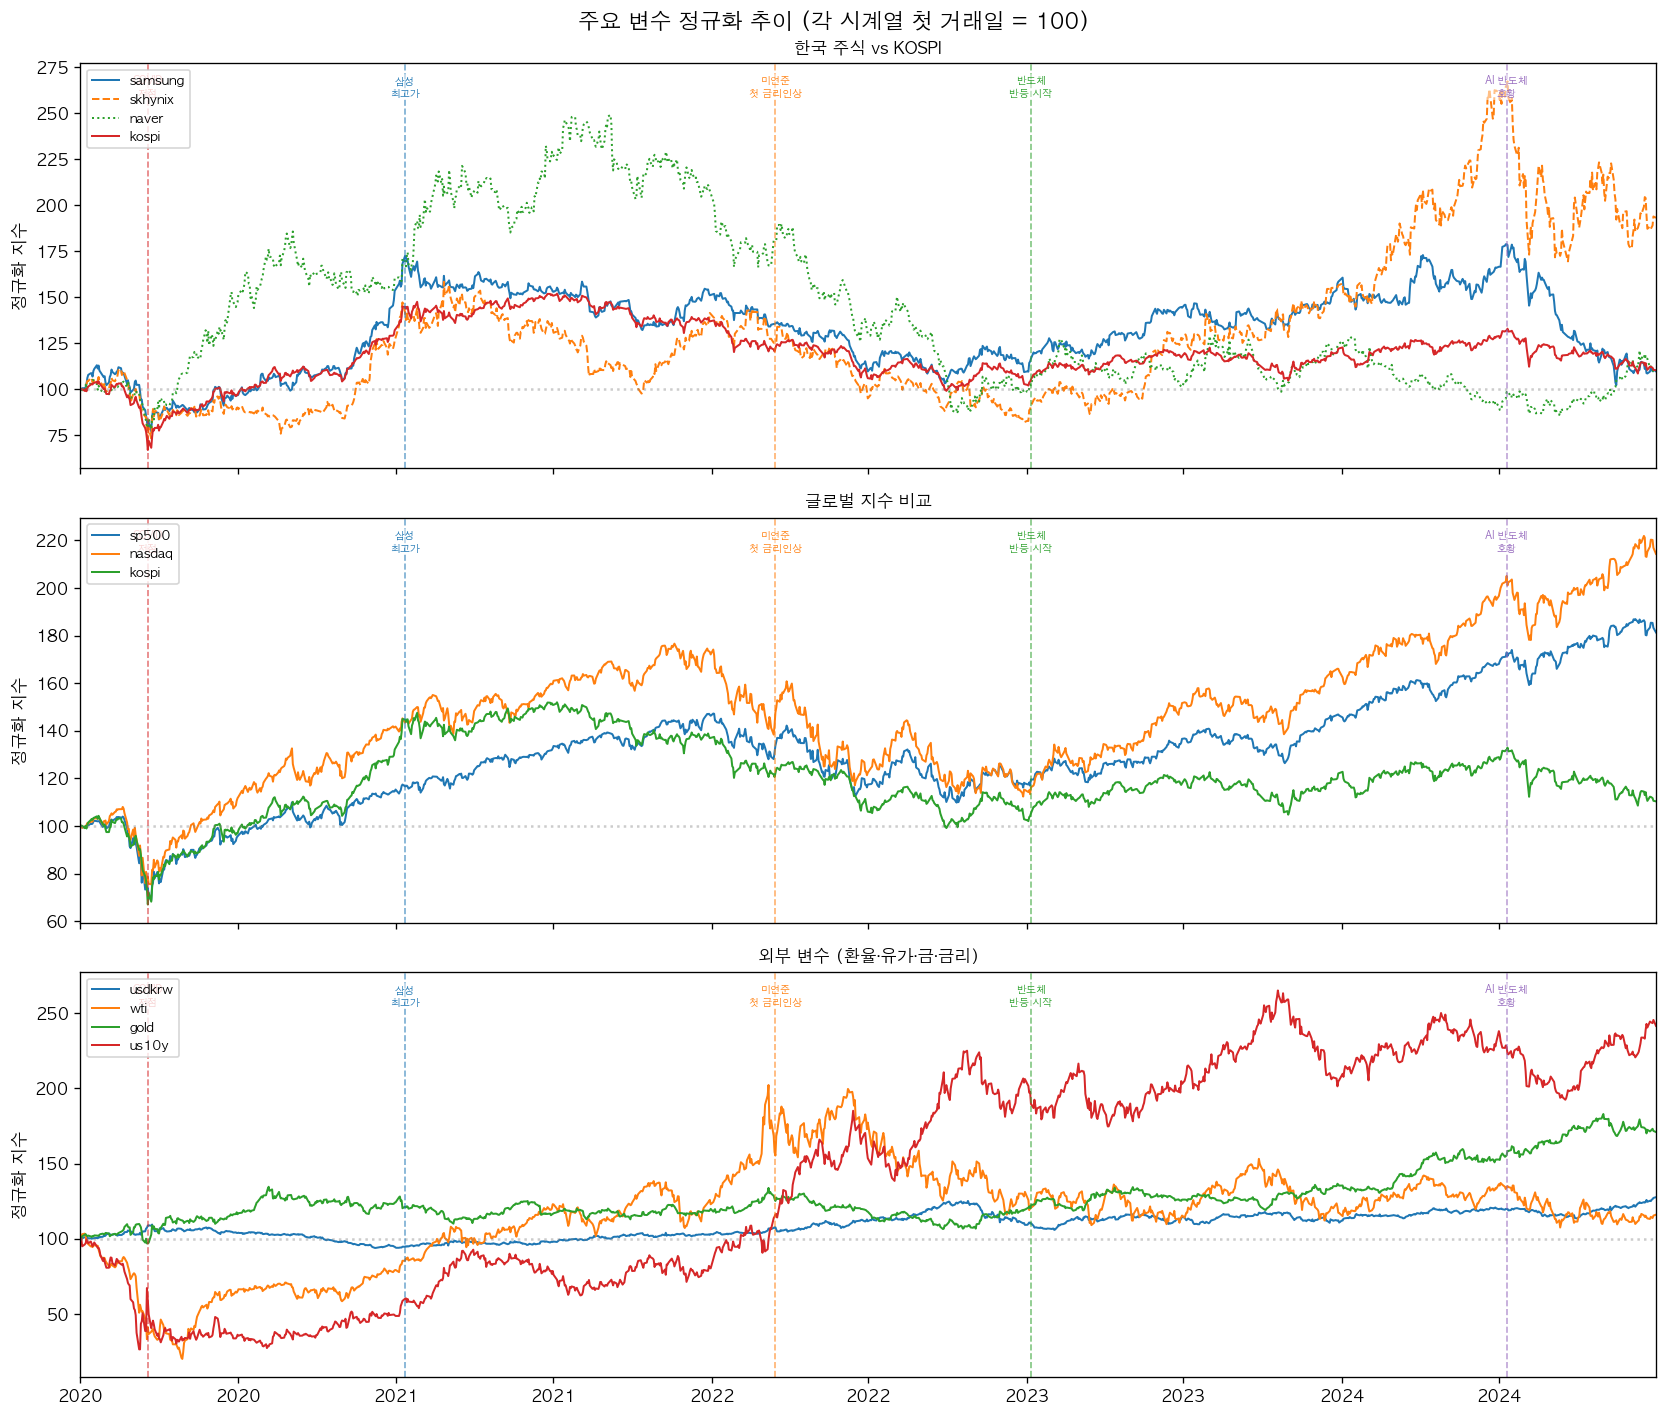

In [4]:
# ── 주요 이벤트 정의 ─────────────────────────────────────────
EVENTS = [
    {'date': '2020-03-19', 'label': 'COVID\n저점',    'color': '#d62728'},
    {'date': '2021-01-11', 'label': '삼성\n최고가',    'color': '#1f77b4'},
    {'date': '2022-03-16', 'label': '미연준\n첫 금리인상', 'color': '#ff7f0e'},
    {'date': '2023-01-06', 'label': '반도체\n반등 시작', 'color': '#2ca02c'},
    {'date': '2024-07-10', 'label': 'AI 반도체\n호황',  'color': '#9467bd'},
]

def add_events(ax):
    for ev in EVENTS:
        ax.axvline(pd.Timestamp(ev['date']), color=ev['color'],
                   linestyle='--', alpha=0.6, linewidth=1)
        ylim = ax.get_ylim()
        y_pos = ylim[0] + (ylim[1] - ylim[0]) * 0.97
        ax.text(pd.Timestamp(ev['date']), y_pos, ev['label'],
                fontsize=6, ha='center', va='top', color=ev['color'],
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.5, edgecolor='none'))

# 정규화: 각 컬럼별 첫 유효값(non-NaN) 기준
first_valid = master.apply(lambda col: col.dropna().iloc[0])
norm = master.div(first_valid) * 100

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('주요 변수 정규화 추이 (각 시계열 첫 거래일 = 100)', fontsize=13, fontweight='bold')

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

ax = axes[0]
for i, (col, style) in enumerate([('samsung', '-'), ('skhynix', '--'), ('naver', ':'), ('kospi', '-')]):
    s = norm[col].dropna()
    ax.plot(s.index, s.values, label=col, linewidth=1.2, linestyle=style, color=color_cycle[i % len(color_cycle)])
ax.set_title('한국 주식 vs KOSPI', fontsize=10)
ax.set_ylabel('정규화 지수')
ax.legend(fontsize=8, loc='upper left')
ax.axhline(100, color='gray', linestyle=':', alpha=0.4)
add_events(ax)

ax = axes[1]
for i, col in enumerate(['sp500', 'nasdaq', 'kospi']):
    s = norm[col].dropna()
    ax.plot(s.index, s.values, label=col, linewidth=1.2, color=color_cycle[i % len(color_cycle)])
ax.set_title('글로벌 지수 비교', fontsize=10)
ax.set_ylabel('정규화 지수')
ax.legend(fontsize=8, loc='upper left')
ax.axhline(100, color='gray', linestyle=':', alpha=0.4)
add_events(ax)

ax = axes[2]
for i, col in enumerate(['usdkrw', 'wti', 'gold', 'us10y']):
    s = norm[col].dropna()
    ax.plot(s.index, s.values, label=col, linewidth=1.2, color=color_cycle[i % len(color_cycle)])
ax.set_title('외부 변수 (환율·유가·금·금리)', fontsize=10)
ax.set_ylabel('정규화 지수')
ax.legend(fontsize=8, loc='upper left')
ax.axhline(100, color='gray', linestyle=':', alpha=0.4)
add_events(ax)

# xlim 명시 + DateFormatter (MonthLocator 제거)
date_min = master.apply(lambda c: c.dropna().index.min()).min()
date_max = master.index.max()
axes[-1].set_xlim(date_min, date_max)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=0, ha='center')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_normalized_trends.png', bbox_inches='tight')
plt.show()


## 3. 상관관계 분석

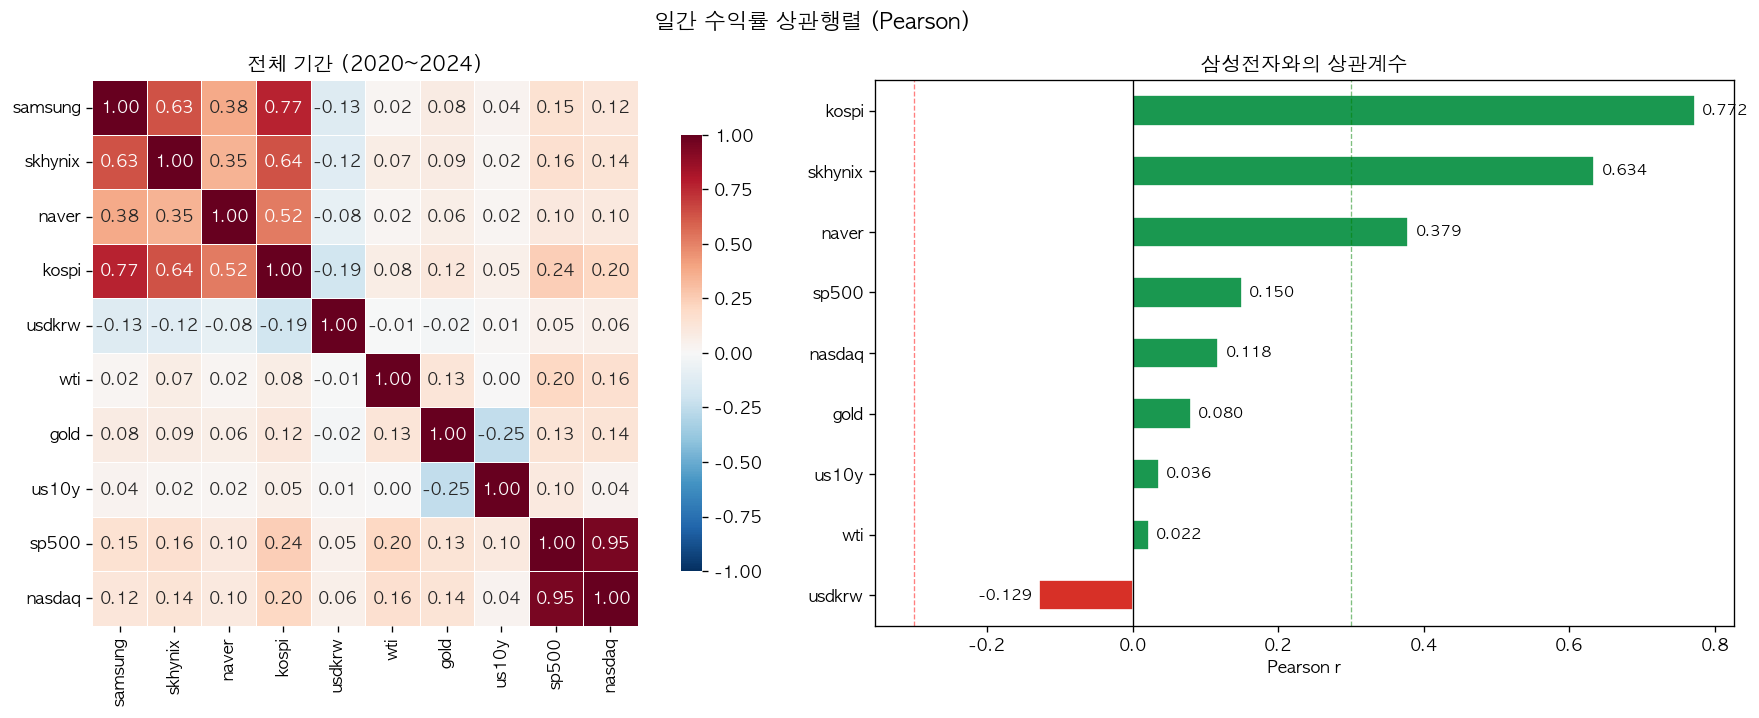


=== 삼성전자와의 상관계수 (강도 순) ===
kospi      0.772134
skhynix    0.634460
naver      0.378900
sp500      0.149582
nasdaq     0.117589
gold       0.079882
us10y      0.036219
wti        0.021806
usdkrw    -0.128797


In [5]:
# ── 전체 기간 상관행렬 ────────────────────────────────────────
corr_matrix = returns.corr(method='pearson')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('일간 수익률 상관행렬 (Pearson)', fontsize=13, fontweight='bold')

# 전체 상관행렬
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, ax=axes[0], annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[0].set_title('전체 기간 (2020~2024)')

# 삼성전자와의 상관계수 바차트
samsung_corr = corr_matrix['samsung'].drop('samsung').sort_values()
colors = ['#d73027' if v < 0 else '#1a9850' for v in samsung_corr]
samsung_corr.plot(kind='barh', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('삼성전자와의 상관계수')
axes[1].set_xlabel('Pearson r')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].axvline(0.3, color='green', linestyle='--', alpha=0.5, linewidth=0.8)
axes[1].axvline(-0.3, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
for i, v in enumerate(samsung_corr):
    axes[1].text(v + (0.01 if v >= 0 else -0.01), i,
                 f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_correlation_matrix.png', bbox_inches='tight')
plt.show()

print('\n=== 삼성전자와의 상관계수 (강도 순) ===')
print(samsung_corr.sort_values(ascending=False).to_string())

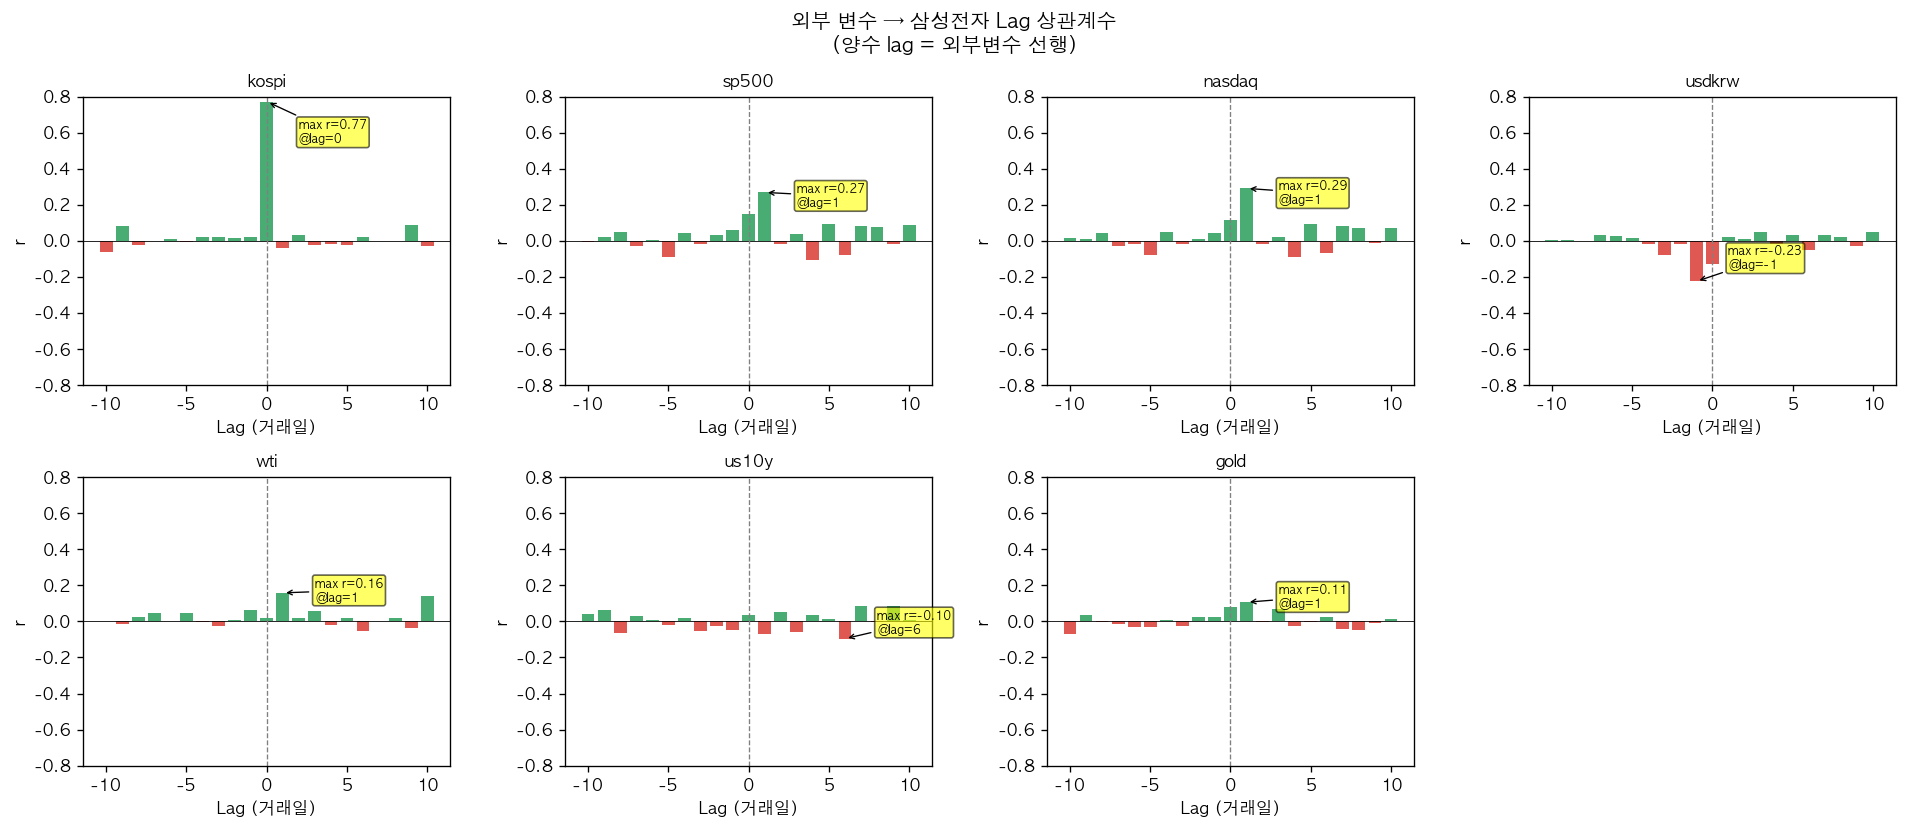

In [6]:
# ── Lag 상관관계: 외부 변수가 삼성전자에 선행하는가? ──────────
lag_vars  = ['kospi', 'sp500', 'nasdaq', 'usdkrw', 'wti', 'us10y', 'gold']
max_lag   = 10   # ±10 거래일
lags      = range(-max_lag, max_lag + 1)

lag_corr = pd.DataFrame(index=lags, columns=lag_vars, dtype=float)

for var in lag_vars:
    for lag in lags:
        shifted = returns[var].shift(lag)      # lag>0: var가 삼성전자보다 lag일 선행
        lag_corr.loc[lag, var] = returns['samsung'].corr(shifted)

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
fig.suptitle('외부 변수 → 삼성전자 Lag 상관계수\n(양수 lag = 외부변수 선행)', fontsize=12, fontweight='bold')
axes_flat = axes.flatten()

for i, var in enumerate(lag_vars):
    ax = axes_flat[i]
    vals = lag_corr[var].astype(float)
    colors = ['#d73027' if v < 0 else '#1a9850' for v in vals]
    ax.bar(lags, vals, color=colors, alpha=0.8, width=0.8)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='gray',  linewidth=0.8, linestyle='--')
    ax.set_title(var, fontsize=10)
    ax.set_xlabel('Lag (거래일)')
    ax.set_ylabel('r')
    ax.set_ylim(-0.8, 0.8)

    # 최대 상관 lag 표시
    best_lag = vals.abs().idxmax()
    best_val = vals[best_lag]
    ax.annotate(f'max r={best_val:.2f}\n@lag={best_lag}',
                xy=(best_lag, best_val), xytext=(best_lag + 2, best_val * 0.7),
                fontsize=7, arrowprops=dict(arrowstyle='->', lw=0.8),
                bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.6))

axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_lag_correlation.png', bbox_inches='tight')
plt.show()

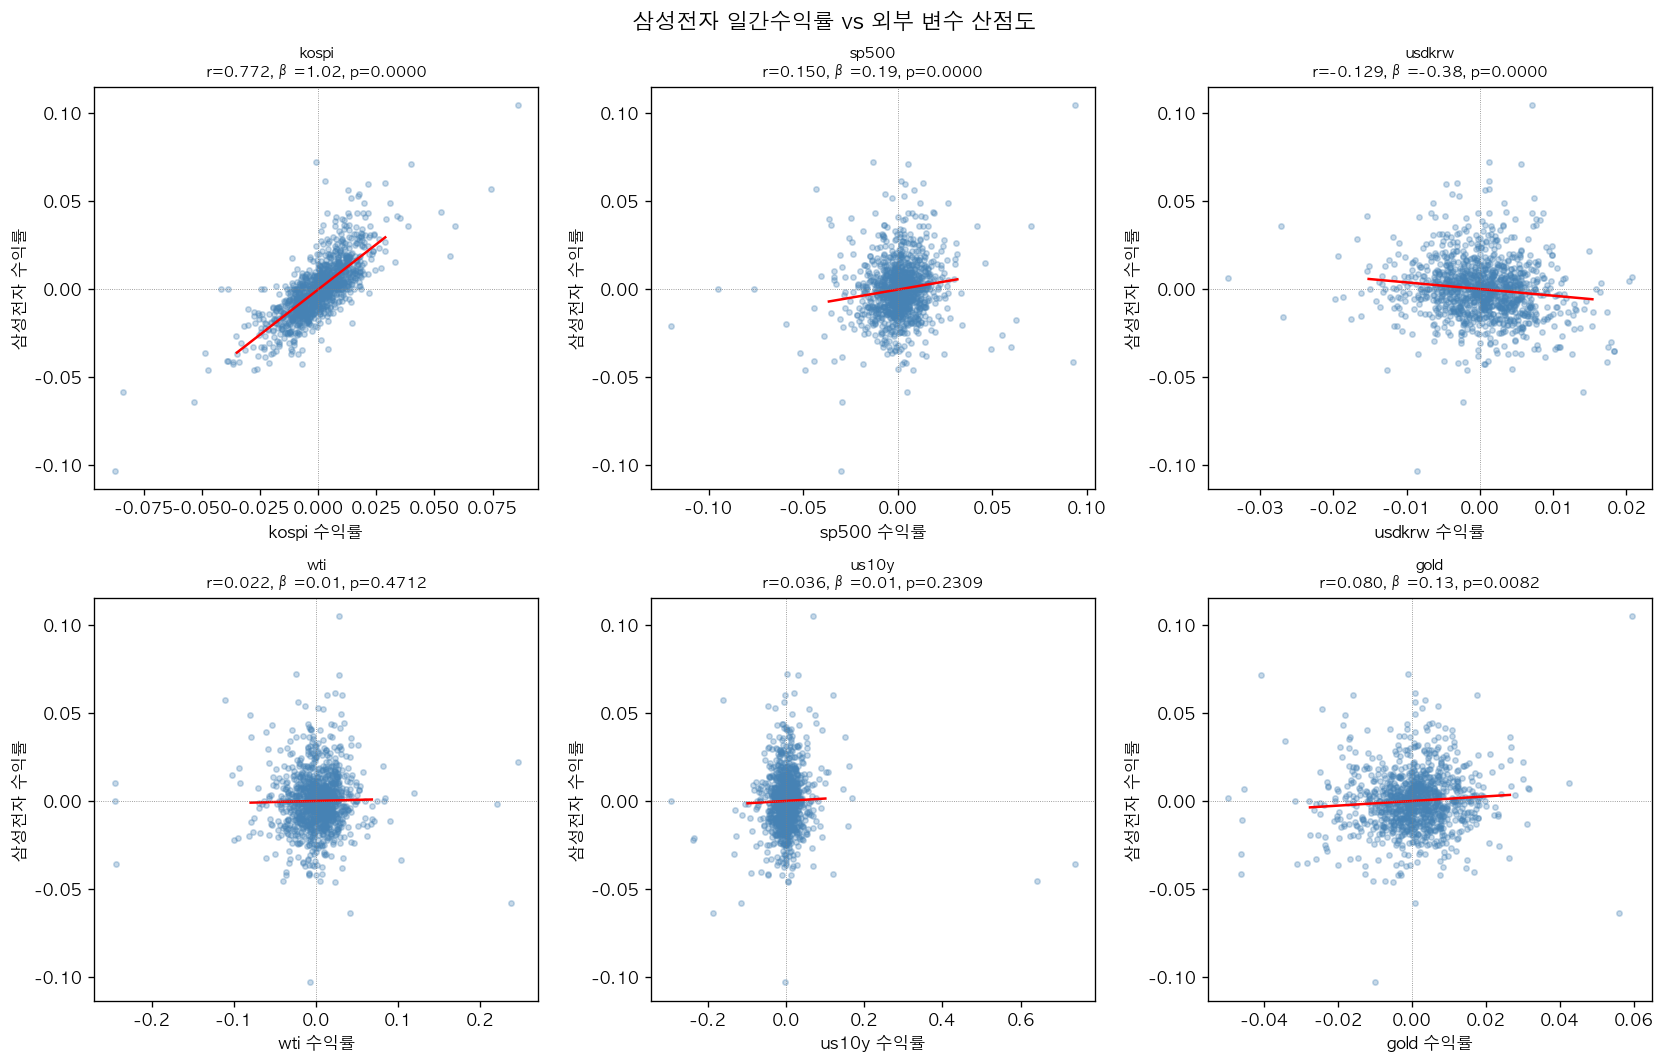

In [7]:
# ── 산점도: 삼성전자 수익률 vs 주요 외부 변수 ─────────────────
scatter_vars = ['kospi', 'sp500', 'usdkrw', 'wti', 'us10y', 'gold']

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('삼성전자 일간수익률 vs 외부 변수 산점도', fontsize=13, fontweight='bold')

for ax, var in zip(axes.flatten(), scatter_vars):
    x = returns[var].dropna()
    y = returns['samsung'].dropna()
    common_idx = x.index.intersection(y.index)
    x, y = x[common_idx], y[common_idx]

    ax.scatter(x, y, alpha=0.3, s=10, color='steelblue')

    # 회귀선
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.quantile(0.01), x.quantile(0.99), 100)
    ax.plot(x_line, slope * x_line + intercept, 'r-', lw=1.5)

    ax.set_title(f'{var}\nr={r:.3f}, β={slope:.2f}, p={p:.4f}', fontsize=9)
    ax.set_xlabel(f'{var} 수익률')
    ax.set_ylabel('삼성전자 수익률')
    ax.axhline(0, color='gray', lw=0.5, linestyle=':')
    ax.axvline(0, color='gray', lw=0.5, linestyle=':')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_scatter_plots.png', bbox_inches='tight')
plt.show()

## 4. 롤링 상관계수 (시간에 따른 관계 변화)

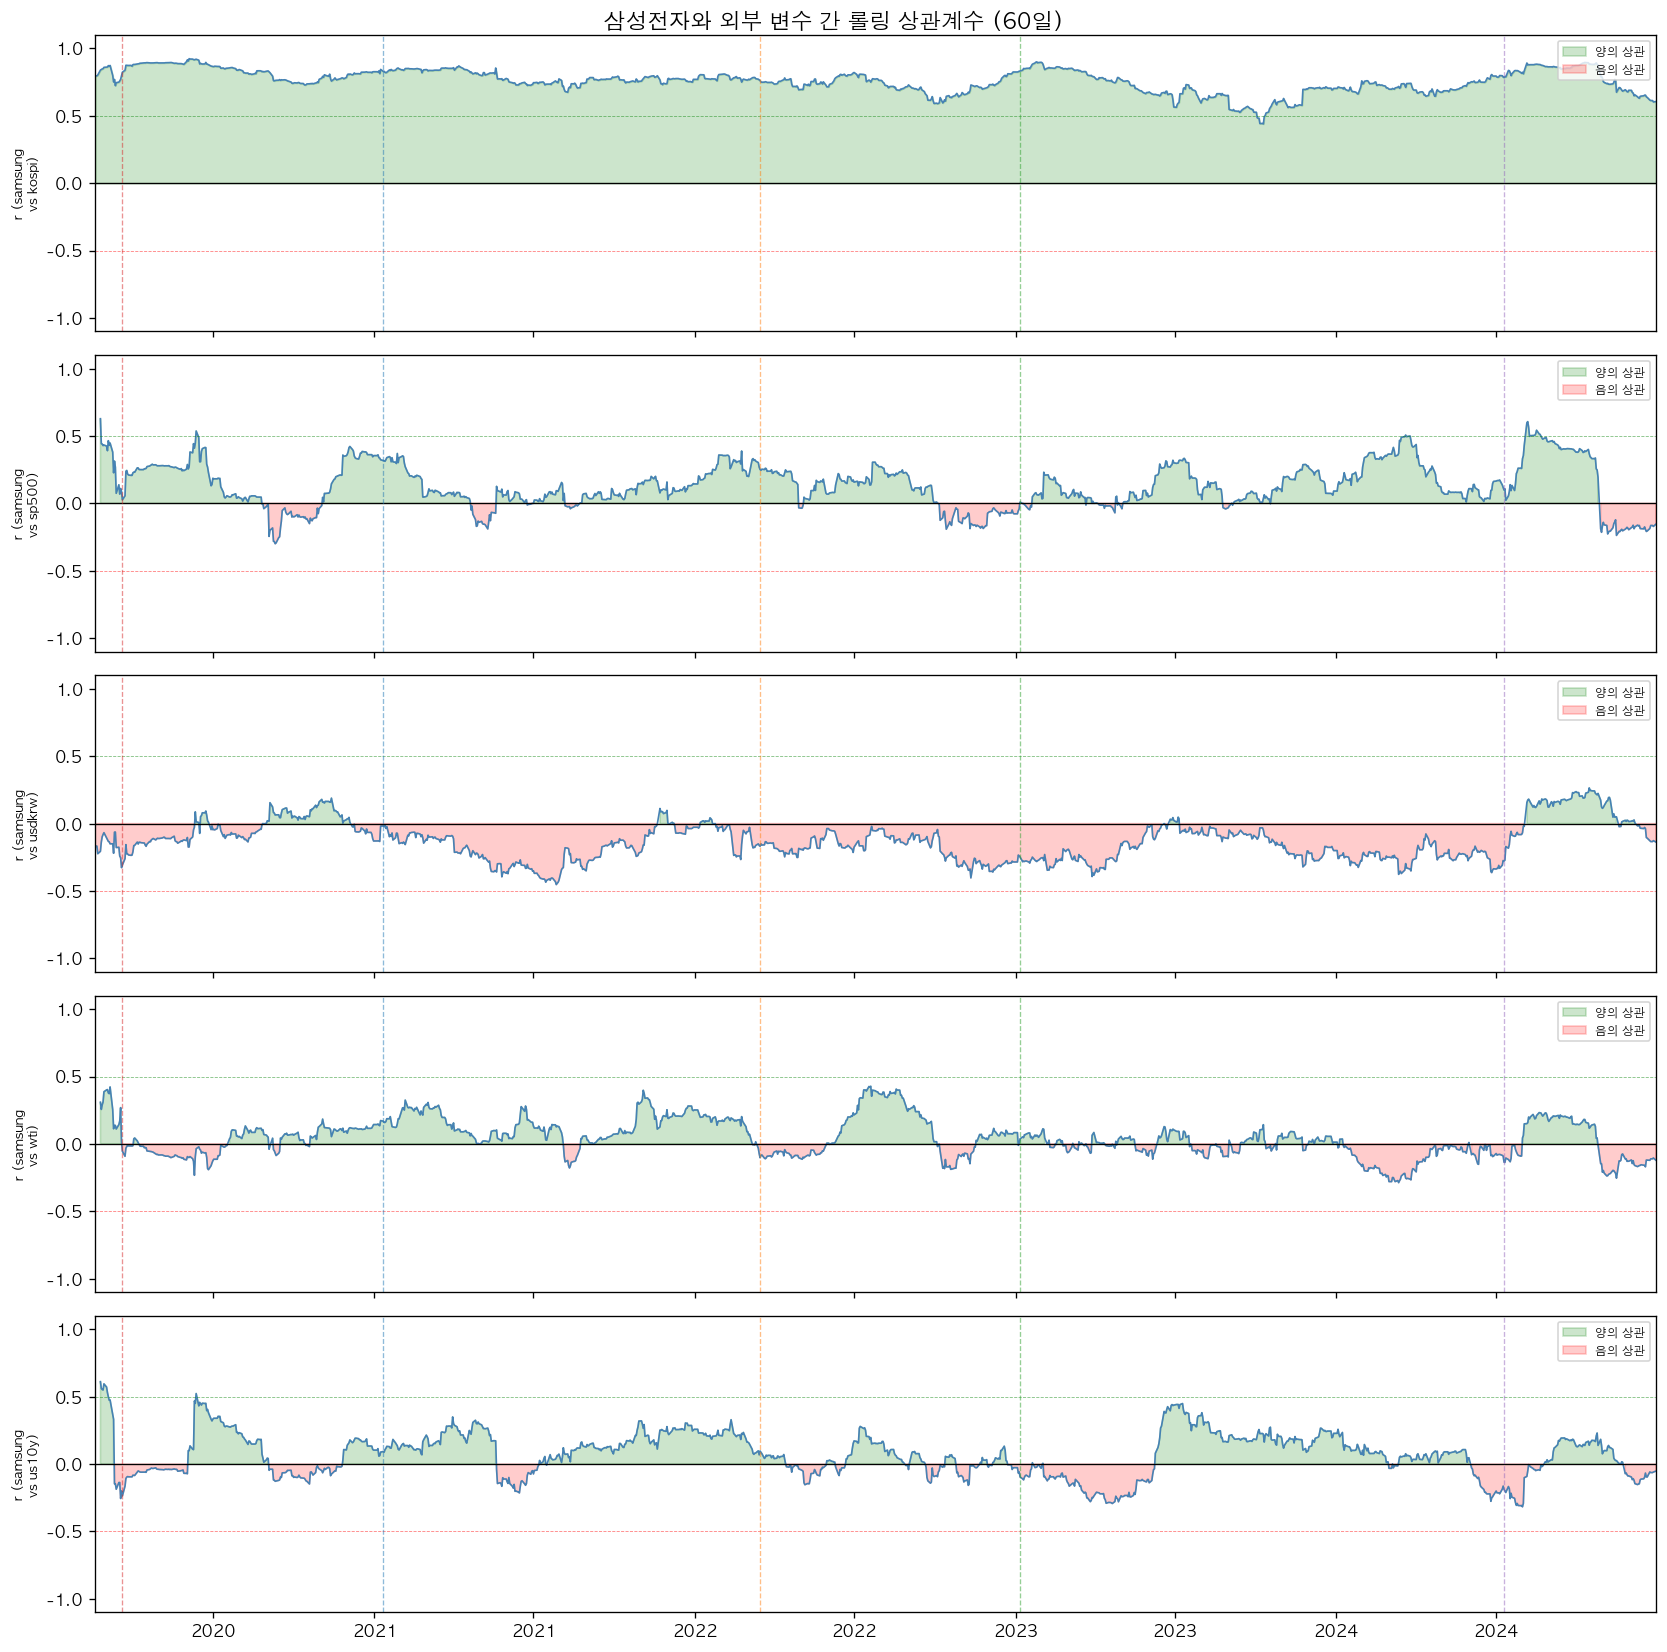

In [8]:
WINDOW = 60
rolling_corr_vars = ['kospi', 'sp500', 'usdkrw', 'wti', 'us10y']

rolling_corrs = pd.DataFrame({
    var: returns['samsung'].rolling(WINDOW, min_periods=30).corr(returns[var])
    for var in rolling_corr_vars
})

valid_start = rolling_corrs.dropna(how='all').index.min()
valid_end   = rolling_corrs.index.max()

fig, axes = plt.subplots(len(rolling_corr_vars), 1, figsize=(14, 14), sharex=True)
fig.suptitle(f'삼성전자와 외부 변수 간 롤링 상관계수 ({WINDOW}일)', fontsize=13, fontweight='bold')

for ax, var in zip(axes, rolling_corr_vars):
    r = rolling_corrs[var].dropna()
    ax.plot(r.index, r.values, linewidth=1, color='steelblue')
    ax.fill_between(r.index, r.values, 0, where=(r.values > 0), alpha=0.2, color='green', label='양의 상관')
    ax.fill_between(r.index, r.values, 0, where=(r.values < 0), alpha=0.2, color='red',   label='음의 상관')
    ax.axhline(0,    color='black', lw=0.8)
    ax.axhline(0.5,  color='green', lw=0.5, linestyle='--', alpha=0.5)
    ax.axhline(-0.5, color='red',   lw=0.5, linestyle='--', alpha=0.5)
    ax.set_ylabel(f'r (samsung\nvs {var})', fontsize=8)
    ax.set_ylim(-1.1, 1.1)
    ax.legend(fontsize=7, loc='upper right')
    for ev in EVENTS:
        ax.axvline(pd.Timestamp(ev['date']), color=ev['color'], linestyle='--', alpha=0.5, lw=0.8)

axes[-1].set_xlim(valid_start, valid_end)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=0, ha='center')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig6_rolling_correlation.png', bbox_inches='tight')
plt.show()


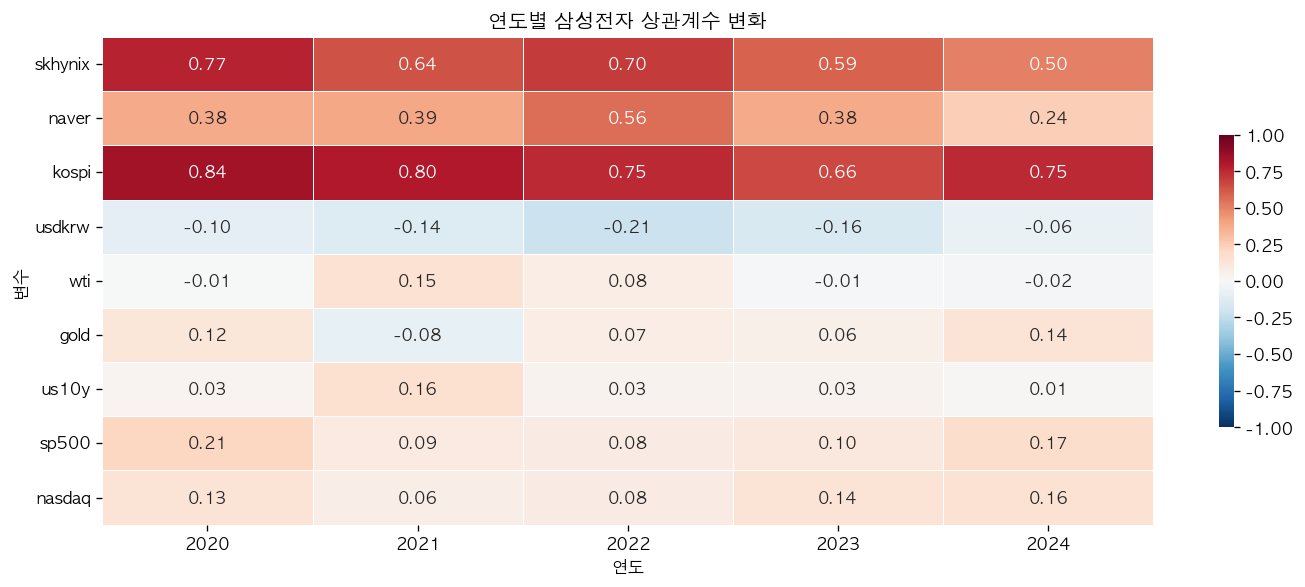


=== 연도별 삼성전자 상관계수 ===


,2020,2021,2022,2023,2024
skhynix,0.773,0.635,0.702,0.591,0.504
naver,0.375,0.388,0.561,0.382,0.242
kospi,0.837,0.798,0.750,0.661,0.747
usdkrw,-0.099,-0.140,-0.213,-0.160,-0.065
wti,-0.006,0.153,0.077,-0.015,-0.017
gold,0.121,-0.080,0.072,0.059,0.138
us10y,0.028,0.162,0.032,0.033,0.013
sp500,0.213,0.091,0.080,0.105,0.174
nasdaq,0.135,0.065,0.082,0.139,0.156


In [9]:
# ── 연도별 상관계수 히트맵 ────────────────────────────────────
years = [2020, 2021, 2022, 2023, 2024]
corr_by_year = {}

for yr in years:
    yr_ret = returns[returns.index.year == yr]
    corr_by_year[yr] = yr_ret.corr()['samsung'].drop('samsung')

yearly_corr_df = pd.DataFrame(corr_by_year).T   # index=year, columns=variables

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(yearly_corr_df.T, ax=ax, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.6})
ax.set_title('연도별 삼성전자 상관계수 변화', fontsize=12, fontweight='bold')
ax.set_xlabel('연도')
ax.set_ylabel('변수')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig7_yearly_correlation.png', bbox_inches='tight')
plt.show()

print('\n=== 연도별 삼성전자 상관계수 ===')
display(yearly_corr_df.T.round(3))

## 5. 이벤트 전후 주가 반응 분석

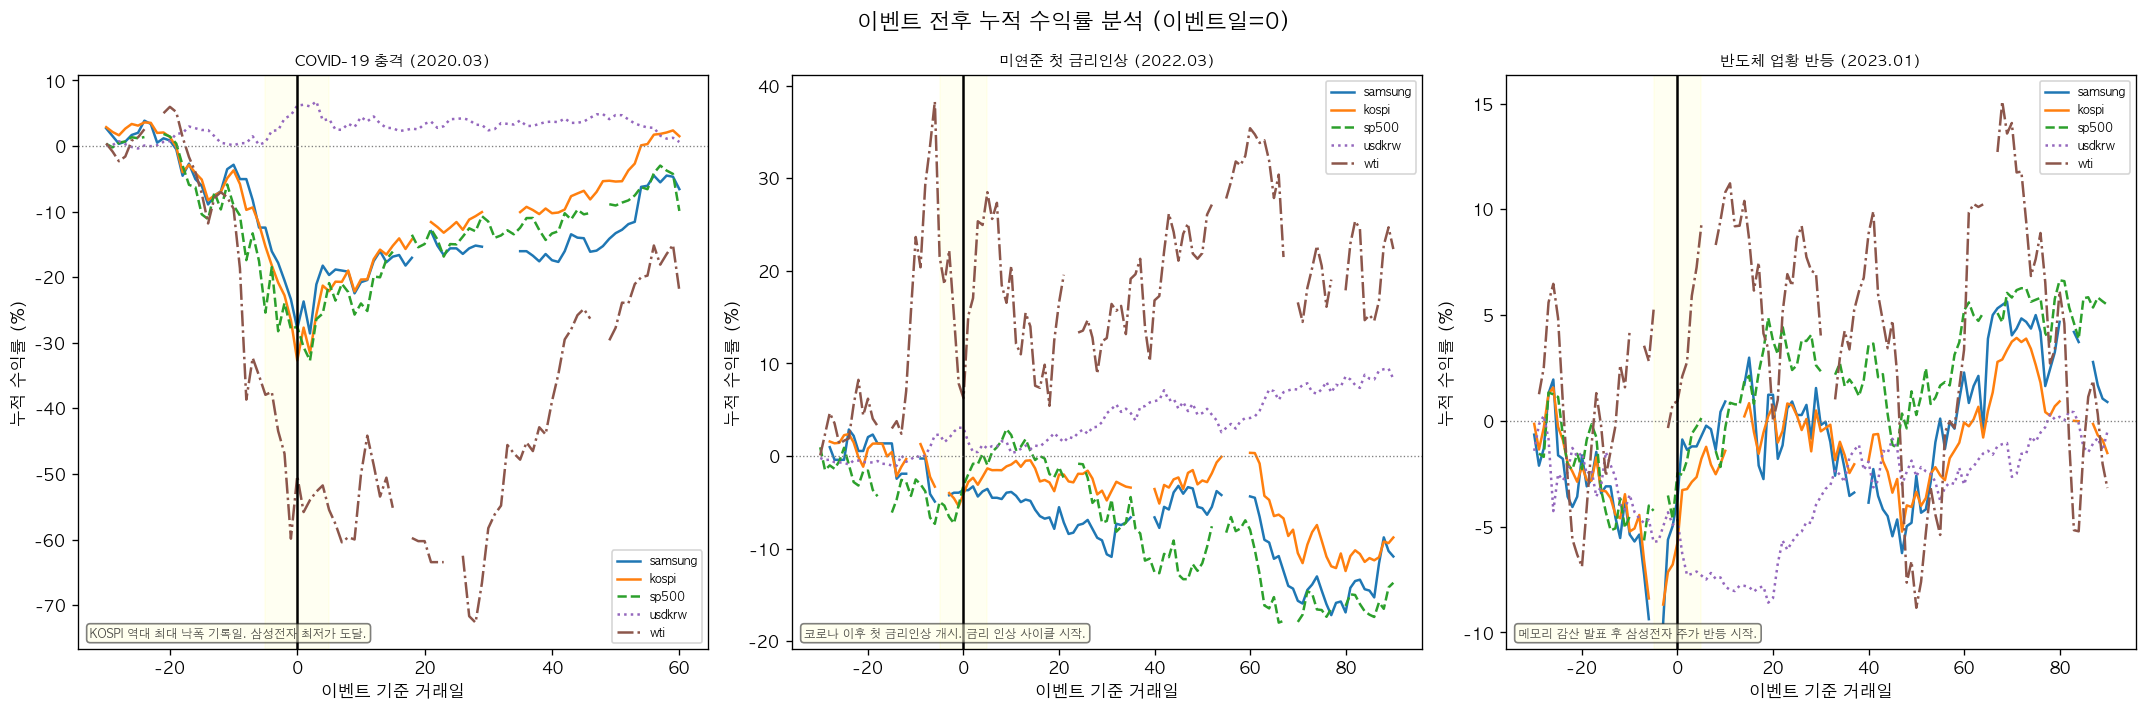

In [10]:
# ── 이벤트 스터디: 이벤트 전후 누적 수익률 ──────────────────
EVENT_STUDIES = [
    {
        'name':  'COVID-19 충격 (2020.03)',
        'date':  '2020-03-19',
        'desc':  'KOSPI 역대 최대 낙폭 기록일. 삼성전자 최저가 도달.',
        'color': '#d62728',
        'window': (-30, 60),   # 이벤트 전 30일 ~ 후 60일
    },
    {
        'name':  '미연준 첫 금리인상 (2022.03)',
        'date':  '2022-03-16',
        'desc':  '코로나 이후 첫 금리인상 개시. 금리 인상 사이클 시작.',
        'color': '#ff7f0e',
        'window': (-30, 90),
    },
    {
        'name':  '반도체 업황 반등 (2023.01)',
        'date':  '2023-01-06',
        'desc':  '메모리 감산 발표 후 삼성전자 주가 반등 시작.',
        'color': '#2ca02c',
        'window': (-30, 90),
    },
]

def event_study(event: dict, assets: list, returns_df: pd.DataFrame) -> dict:
    """
    이벤트일 기준 전후 누적 수익률을 계산한다.
    
    Returns: {asset: pd.Series(index=relative_day, values=cumret)}
    """
    event_date = pd.Timestamp(event['date'])
    # 이벤트일에 가장 가까운 실제 거래일
    idx = returns_df.index
    closest = idx[idx.get_indexer([event_date], method='nearest')[0]]
    pos = idx.get_loc(closest)

    pre, post = event['window']
    start_pos = max(0, pos + pre)
    end_pos   = min(len(idx) - 1, pos + post)

    result = {}
    for asset in assets:
        window_ret = returns_df[asset].iloc[start_pos: end_pos + 1]
        rel_days   = range(pre, pre + len(window_ret))
        cum_ret    = (1 + window_ret).cumprod() - 1
        result[asset] = pd.Series(cum_ret.values, index=rel_days)
    return result


STUDY_ASSETS = ['samsung', 'kospi', 'sp500', 'usdkrw', 'wti']

fig, axes = plt.subplots(1, len(EVENT_STUDIES), figsize=(18, 6))
fig.suptitle('이벤트 전후 누적 수익률 분석 (이벤트일=0)', fontsize=13, fontweight='bold')

for ax, ev in zip(axes, EVENT_STUDIES):
    study = event_study(ev, STUDY_ASSETS, returns)

    styles = ['-', '-', '--', ':', '-.']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']

    for (asset, ser), ls, col in zip(study.items(), styles, colors):
        ax.plot(ser.index, ser * 100, label=asset, linestyle=ls, color=col, lw=1.5)

    ax.axvline(0, color='black', lw=1.5, linestyle='-')
    ax.axhline(0, color='gray',  lw=0.8, linestyle=':')
    ax.axvspan(-5, 5, alpha=0.05, color='yellow')  # 이벤트 직전후 강조
    ax.set_title(ev['name'], fontsize=9, fontweight='bold')
    ax.set_xlabel('이벤트 기준 거래일')
    ax.set_ylabel('누적 수익률 (%)')
    ax.legend(fontsize=7)
    ax.annotate(ev['desc'], xy=(0.02, 0.02), xycoords='axes fraction',
                fontsize=7, alpha=0.7,
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig8_event_study.png', bbox_inches='tight')
plt.show()

In [11]:
# ── 이벤트 전후 수치 요약 ─────────────────────────────────────
summary_rows = []

for ev in EVENT_STUDIES:
    study = event_study(ev, STUDY_ASSETS, returns)
    for asset, ser in study.items():
        pre_ret  = ser[ser.index < 0].iloc[-1]  if len(ser[ser.index < 0]) > 0 else 0
        t1_ret   = ser.get(1, np.nan)
        t5_ret   = ser.get(5, np.nan)
        t20_ret  = ser.get(20, np.nan)
        t60_ret  = ser.get(60, ser.iloc[-1] if len(ser) > 0 else np.nan)
        summary_rows.append({
            '이벤트':   ev['name'][:10],
            '자산':     asset,
            '사전(%)'  : round(pre_ret  * 100, 2),
            '+1일(%)'  : round(t1_ret   * 100, 2) if not np.isnan(t1_ret)  else None,
            '+5일(%)'  : round(t5_ret   * 100, 2) if not np.isnan(t5_ret)  else None,
            '+20일(%)' : round(t20_ret  * 100, 2) if not np.isnan(t20_ret) else None,
            '+60일(%)' : round(t60_ret  * 100, 2) if not np.isnan(t60_ret) else None,
        })

event_summary = pd.DataFrame(summary_rows).set_index(['이벤트', '자산'])
display(event_summary.style
    .background_gradient(subset=['+1일(%)', '+5일(%)', '+20일(%)', '+60일(%)'],
                         cmap='RdYlGn', vmin=-30, vmax=30)
    .format('{:.2f}', na_rep='N/A')
)

## 6. 변동성 분석

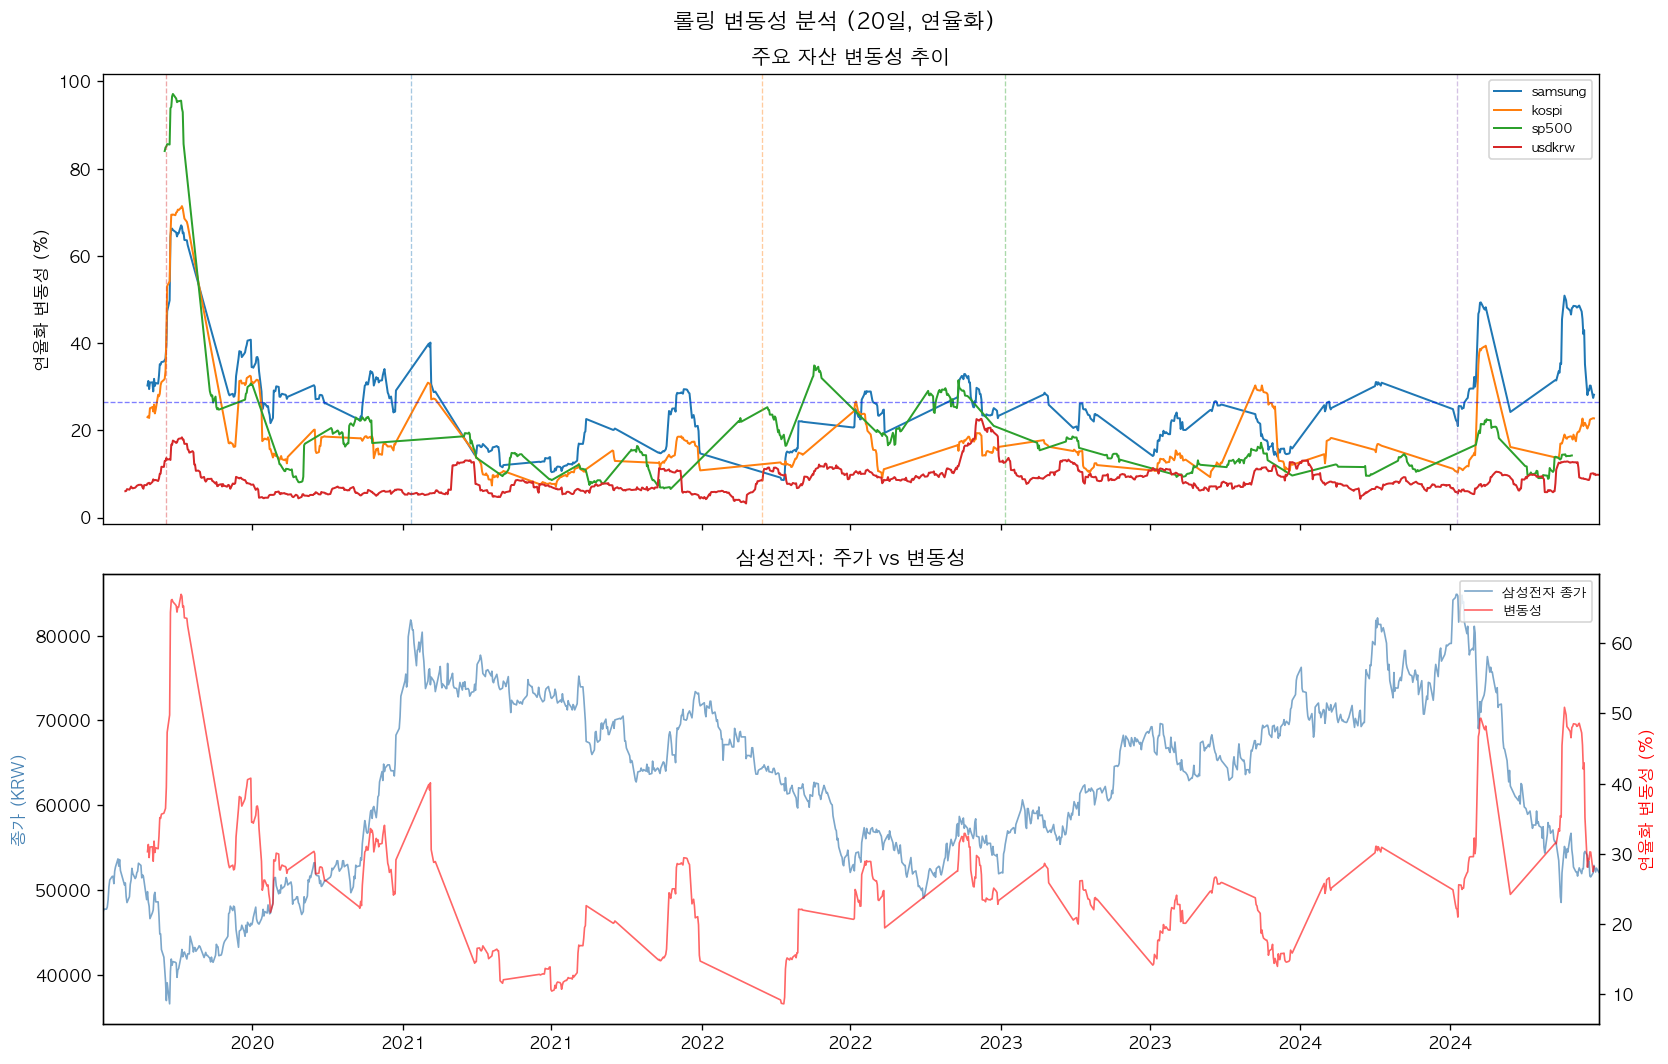

In [12]:
VOL_WINDOW = 20
vol_assets = ['samsung', 'kospi', 'sp500', 'usdkrw']

rolling_vol = returns[vol_assets].rolling(VOL_WINDOW).std() * np.sqrt(252) * 100

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('롤링 변동성 분석 (20일, 연율화)', fontsize=13, fontweight='bold')

ax = axes[0]
for i, col in enumerate(vol_assets):
    s = rolling_vol[col].dropna()
    ax.plot(s.index, s.values, label=col, lw=1.2, color=color_cycle[i % len(color_cycle)])
ax.set_ylabel('연율화 변동성 (%)')
ax.set_title('주요 자산 변동성 추이')
ax.legend(fontsize=8)
ax.axhline(rolling_vol['samsung'].mean(), color='blue', linestyle='--', alpha=0.5, lw=0.8)
for ev in EVENTS:
    ax.axvline(pd.Timestamp(ev['date']), color=ev['color'], linestyle='--', alpha=0.4, lw=0.8)

ax2  = axes[1]
ax2b = ax2.twinx()
samsung_clean = master['samsung'].dropna()
vol_clean     = rolling_vol['samsung'].dropna()
ax2.plot(samsung_clean.index,  samsung_clean.values,  color='steelblue', lw=1, label='삼성전자 종가', alpha=0.7)
ax2b.plot(vol_clean.index, vol_clean.values, color='red', lw=1, label='변동성', alpha=0.6)
ax2.set_ylabel('종가 (KRW)', color='steelblue')
ax2b.set_ylabel('연율화 변동성 (%)', color='red')
ax2.set_title('삼성전자: 주가 vs 변동성')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')

axes[-1].set_xlim(samsung_clean.index.min(), samsung_clean.index.max())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=0, ha='center')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig9_volatility.png', bbox_inches='tight')
plt.show()


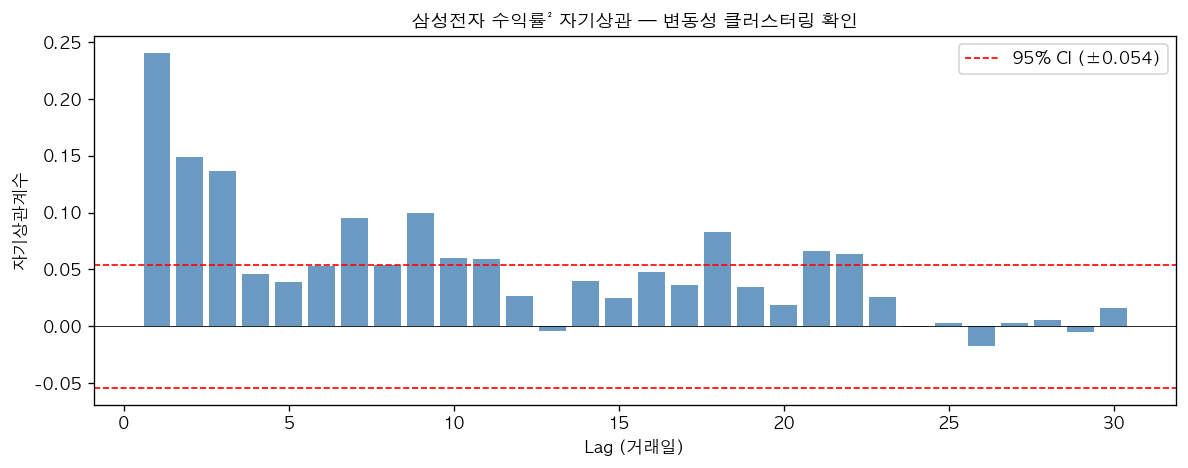

95% 신뢰구간 초과 lag: [1, 2, 3, 7, 9, 10, 11, 18, 21, 22]
→ 변동성 클러스터링 확인됨 (ARCH 효과)


In [13]:
# ── 변동성 클러스터링 확인 (자기상관) ─────────────────────────
sq_ret = returns['samsung'] ** 2   # 수익률 제곱 = 변동성 프록시

autocorr_lags = range(1, 31)
autocorr_vals = [sq_ret.autocorr(lag) for lag in autocorr_lags]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(autocorr_lags, autocorr_vals, color='steelblue', alpha=0.8)
conf_bound = 1.96 / np.sqrt(len(sq_ret))
ax.axhline(conf_bound, color='red', linestyle='--', lw=1, label=f'95% CI (±{conf_bound:.3f})')
ax.axhline(-conf_bound, color='red', linestyle='--', lw=1)
ax.axhline(0, color='black', lw=0.5)
ax.set_title('삼성전자 수익률² 자기상관 — 변동성 클러스터링 확인', fontsize=11, fontweight='bold')
ax.set_xlabel('Lag (거래일)')
ax.set_ylabel('자기상관계수')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig10_volatility_clustering.png', bbox_inches='tight')
plt.show()

sig_lags = [l for l, v in zip(autocorr_lags, autocorr_vals) if abs(v) > conf_bound]
print(f'95% 신뢰구간 초과 lag: {sig_lags}')
print(f'→ 변동성 클러스터링 {"확인됨" if len(sig_lags) > 0 else "미확인"} (ARCH 효과)')

## 7. 분석 결과 저장

In [14]:
# 롤링 상관계수 저장
rolling_corrs.to_csv(PROCESSED_DIR / 'rolling_correlation.csv')
# 연도별 상관계수 저장
yearly_corr_df.to_csv(PROCESSED_DIR / 'yearly_correlation.csv')
# 이벤트 분석 결과 저장
event_summary.to_csv(PROCESSED_DIR / 'event_study_results.csv')
# 기초 통계 저장
summary.to_csv(PROCESSED_DIR / 'return_statistics.csv')

print('분석 결과 저장 완료:')
for f in sorted(PROCESSED_DIR.glob('*.csv')):
    print(f'  {f.name}')

분석 결과 저장 완료:
  daily_returns.csv
  data_quality_report.csv
  event_study_results.csv
  master_close.csv
  return_statistics.csv
  rolling_correlation.csv
  yearly_correlation.csv


## 8. Day 2 완료 체크리스트

| 항목 | 상태 |
|------|------|
| 기초 통계 (연수익률·변동성·샤프지수·왜도·첨도) | ✅ |
| 수익률 분포 + 정규성 검정 (Jarque-Bera) | ✅ |
| 정규화 시계열 추이 (이벤트 마커 포함) | ✅ |
| 전체 기간 상관행렬 | ✅ |
| Lag 상관관계 (선행지표 탐색) | ✅ |
| 산점도 + 회귀선 | ✅ |
| 60일 롤링 상관계수 추이 | ✅ |
| 연도별 상관계수 변화 히트맵 | ✅ |
| 이벤트 전후 누적수익률 분석 (3개 이벤트) | ✅ |
| 롤링 변동성 + 변동성 클러스터링 확인 | ✅ |

**다음 단계 (Day 3):** 비즈니스 인사이트 도출, README 및 분석 리포트 작성